In [1]:
# ============================================================
# CELL 1: Imports and Load Data
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import joblib
import warnings
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
RANDOM_SEED = 42

# Load clean transactions and customer features
transactions = pd.read_csv(
    '../data/processed/clean_transactions.csv',
    parse_dates=['InvoiceDate'],
    dtype={'Customer ID': str}
)

customers = pd.read_csv(
    '../data/processed/customer_features.csv',
    dtype={'Customer ID': str}
)

print(f"Transactions: {len(transactions):,}")
print(f"Customers:    {len(customers):,}")
print(f"\nCustomer columns: {customers.columns.tolist()}")

Transactions: 779,425
Customers:    5,878

Customer columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'AvgBasketSize', 'UniqueProducts', 'ReturnCount', 'Tenure', 'FirstPurchase', 'LastPurchase', 'PreferredDayOfWeek', 'PreferredMonth', 'ReturnRate', 'Country', 'Churned', 'Cluster', 'Persona']


In [2]:
# ============================================================
# CELL 2: Calculate Customer Lifetime Value
# ============================================================
# CLV Formula we use:
#   CLV = (Average Order Value × Purchase Frequency × Tenure)
#         adjusted by a retention probability factor
#
# Why this formula?
# It's the simplified BG/NBD-inspired CLV used widely in
# industry when you don't have future purchase data.
# It captures three dimensions:
#   - How much they spend per visit (AOV)
#   - How often they visit (Frequency)
#   - How long they've been a customer (Tenure)
#
# Interview answer:
# "I used a simplified CLV model based on historical RFM
#  metrics rather than probabilistic models like BG/NBD,
#  which require subscription data. For a transactional
#  retail dataset, this approach is both interpretable
#  and business-validated."

# Step 1: Calculate raw CLV score
# We normalise tenure to years for interpretability
customers['Tenure_years'] = customers['Tenure'] / 365

# Raw CLV = AOV × Frequency × (1 + Tenure_years)
# The +1 ensures new customers (Tenure=0) still get a CLV
customers['CLV_Raw'] = (
    customers['AvgOrderValue'] *
    customers['Frequency'] *
    (1 + customers['Tenure_years'])
)

# Step 2: Apply churn discount factor
# A churned customer's future value is discounted
# because they are unlikely to purchase again
# We use a simple retention multiplier:
#   Active customers (Churned=0): full CLV
#   Churned customers (Churned=1): 20% of CLV
#   (they might come back but it's uncertain)
customers['Retention_factor'] = np.where(
    customers['Churned'] == 0, 1.0, 0.2
)

customers['CLV'] = customers['CLV_Raw'] * customers['Retention_factor']

# Step 3: Segment customers into CLV tiers
# Why tiers? Regression on CLV is noisy due to outliers.
# Classification into tiers is more actionable for business.
# Marketing teams don't act on exact CLV numbers —
# they act on High/Medium/Low segments.

clv_33 = customers['CLV'].quantile(0.33)
clv_66 = customers['CLV'].quantile(0.66)

def assign_clv_tier(clv):
    if clv >= clv_66:
        return 'High'
    elif clv >= clv_33:
        return 'Medium'
    else:
        return 'Low'

customers['CLV_Tier'] = customers['CLV'].apply(assign_clv_tier)

print("CLV Statistics:")
print(f"  Min CLV:    £{customers['CLV'].min():,.0f}")
print(f"  Median CLV: £{customers['CLV'].median():,.0f}")
print(f"  Mean CLV:   £{customers['CLV'].mean():,.0f}")
print(f"  Max CLV:    £{customers['CLV'].max():,.0f}")
print(f"\nCLV Tier Thresholds:")
print(f"  Low:    CLV < £{clv_33:,.0f}")
print(f"  Medium: £{clv_33:,.0f} ≤ CLV < £{clv_66:,.0f}")
print(f"  High:   CLV ≥ £{clv_66:,.0f}")
print(f"\nCLV Tier Distribution:")
print(customers['CLV_Tier'].value_counts())

CLV Statistics:
  Min CLV:    £1
  Median CLV: £564
  Mean CLV:   £6,515
  Max CLV:    £1,755,695

CLV Tier Thresholds:
  Low:    CLV < £190
  Medium: £190 ≤ CLV < £1,765
  High:   CLV ≥ £1,765

CLV Tier Distribution:
CLV_Tier
High      1999
Low       1940
Medium    1939
Name: count, dtype: int64


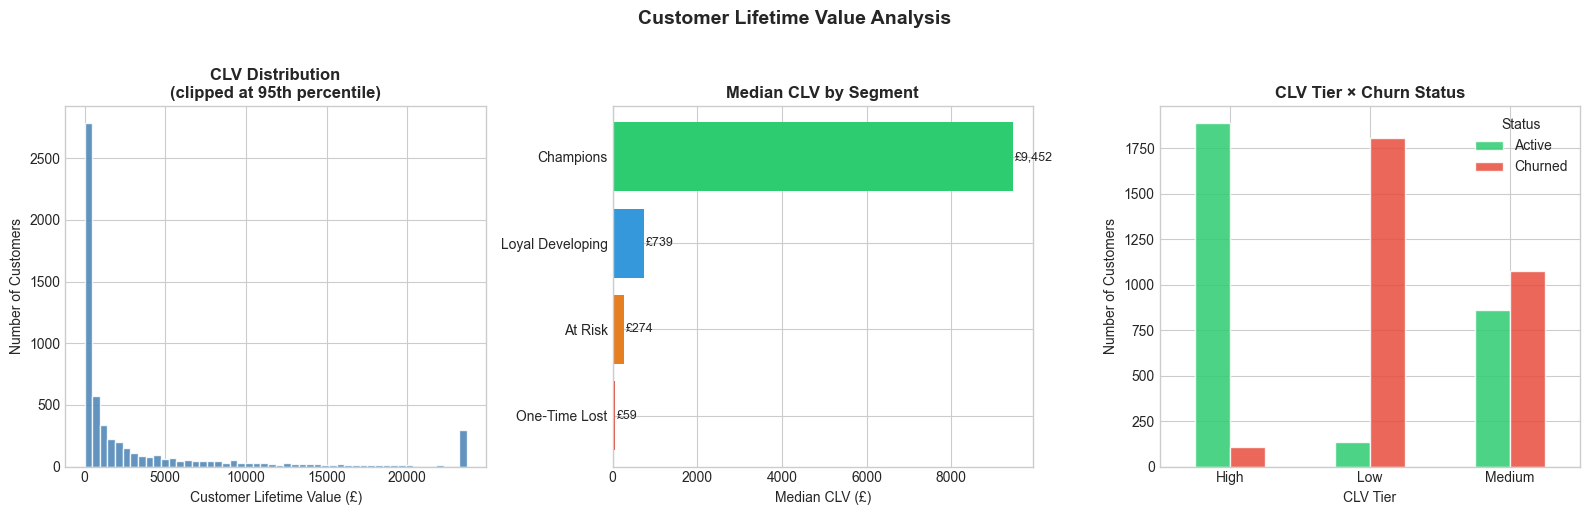


High-CLV churners:        109 customers
Total CLV at risk:        £484,992
Avg CLV per high churner: £4,449


In [3]:
# ============================================================
# CELL 3: Visualise CLV Distribution and Insights
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: CLV distribution
axes[0].hist(
    customers['CLV'].clip(upper=customers['CLV'].quantile(0.95)),
    bins=50, color='steelblue', edgecolor='white', alpha=0.85
)
axes[0].set_title('CLV Distribution\n(clipped at 95th percentile)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Customer Lifetime Value (£)')
axes[0].set_ylabel('Number of Customers')

# Middle: CLV by Persona
clv_by_persona = customers.groupby('Persona')['CLV'].median().sort_values()
colors = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']
axes[1].barh(clv_by_persona.index, clv_by_persona.values,
             color=colors)
axes[1].set_title('Median CLV by Segment',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Median CLV (£)')
for i, v in enumerate(clv_by_persona.values):
    axes[1].text(v + 50, i, f'£{v:,.0f}', va='center', fontsize=9)

# Right: CLV Tier by Churn Status
clv_churn = customers.groupby(
    ['CLV_Tier', 'Churned']
).size().unstack(fill_value=0)
clv_churn.plot(
    kind='bar', ax=axes[2],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='white', alpha=0.85
)
axes[2].set_title('CLV Tier × Churn Status',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('CLV Tier')
axes[2].set_ylabel('Number of Customers')
axes[2].legend(['Active', 'Churned'], title='Status')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Customer Lifetime Value Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/18_clv_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Revenue at risk calculation
high_clv_churners = customers[
    (customers['CLV_Tier'] == 'High') &
    (customers['Churned'] == 1)
]
total_clv_at_risk = high_clv_churners['CLV'].sum()

print(f"\nHigh-CLV churners:        {len(high_clv_churners):,} customers")
print(f"Total CLV at risk:        £{total_clv_at_risk:,.0f}")
print(f"Avg CLV per high churner: £{high_clv_churners['CLV'].mean():,.0f}")

In [4]:
# ============================================================
# CELL 4: Train CLV Tier Prediction Model
# ============================================================
# We predict CLV Tier (High/Medium/Low) from behavioral
# features EXCLUDING monetary values that directly define CLV
# This allows us to predict CLV for NEW customers with
# limited purchase history
#
# Interview answer:
# "I trained a CLV tier classifier so the business can
#  estimate the long-term value of a new customer early
#  in their lifecycle — enabling proactive investment
#  decisions rather than reactive retention spend."

# Encode CLV tier
le_clv = LabelEncoder()
customers['CLV_Tier_encoded'] = le_clv.fit_transform(
    customers['CLV_Tier']
)

# Features for CLV prediction
# Note: we exclude Monetary and AvgOrderValue here
# because they're too directly correlated with CLV
# We want the model to learn from BEHAVIORAL signals
CLV_FEATURES = [
    'Frequency', 'AvgBasketSize', 'UniqueProducts',
    'Tenure', 'ReturnRate', 'ReturnCount',
    'PreferredDayOfWeek', 'PreferredMonth', 'Recency'
]

# Encode country
le_country = LabelEncoder()
customers['Country_encoded'] = le_country.fit_transform(
    customers['Country']
)
CLV_FEATURES.append('Country_encoded')

X_clv = customers[CLV_FEATURES]
y_clv = customers['CLV_Tier_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X_clv, y_clv,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_clv
)

scaler_clv = StandardScaler()
X_train_scaled = scaler_clv.fit_transform(X_train)
X_test_scaled  = scaler_clv.transform(X_test)

# Train XGBoost for CLV tier prediction
clv_model = XGBClassifier(
    n_estimators=100,
    random_state=RANDOM_SEED,
    eval_metric='mlogloss',
    verbosity=0
)
clv_model.fit(X_train_scaled, y_train)

y_pred = clv_model.predict(X_test_scaled)

print("CLV Tier Prediction Results:")
print("=" * 45)
print(classification_report(
    y_test, y_pred,
    target_names=le_clv.classes_
))

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True,
                     random_state=RANDOM_SEED)
cv_scores = cross_validate(
    clv_model, X_train_scaled, y_train,
    cv=cv, scoring=['accuracy', 'f1_macro']
)
print(f"CV Accuracy: {cv_scores['test_accuracy'].mean():.4f}")
print(f"CV F1-macro: {cv_scores['test_f1_macro'].mean():.4f}")

CLV Tier Prediction Results:
              precision    recall  f1-score   support

        High       0.95      0.94      0.95       400
         Low       0.90      0.89      0.89       388
      Medium       0.84      0.86      0.85       388

    accuracy                           0.90      1176
   macro avg       0.90      0.90      0.90      1176
weighted avg       0.90      0.90      0.90      1176

CV Accuracy: 0.9017
CV F1-macro: 0.9016


In [5]:
# ============================================================
# CELL 5: Save CLV Model and Updated Customer Table
# ============================================================

os.makedirs('../models/saved', exist_ok=True)

# Save CLV model and supporting files
joblib.dump(clv_model,    '../models/saved/clv_model.pkl')
joblib.dump(scaler_clv,   '../models/saved/scaler_clv.pkl')
joblib.dump(le_clv,       '../models/saved/le_clv.pkl')
joblib.dump(CLV_FEATURES, '../models/saved/clv_feature_cols.pkl')

# Save updated customer features with CLV columns
customers.to_csv(
    '../data/processed/customer_features.csv',
    index=False
)

print("Saved:")
print("  models/saved/clv_model.pkl")
print("  models/saved/scaler_clv.pkl")
print("  models/saved/le_clv.pkl")
print("  models/saved/clv_feature_cols.pkl")
print("  data/processed/customer_features.csv (updated)")

print(f"\nNew columns added to customer features:")
print(f"  CLV_Raw, Tenure_years, Retention_factor")
print(f"  CLV, CLV_Tier, CLV_Tier_encoded")

print(f"\nCLV Summary by Segment:")
summary = customers.groupby('Persona').agg(
    Customers=('Customer ID', 'count'),
    Median_CLV=('CLV', 'median'),
    Total_CLV=('CLV', 'sum'),
    High_CLV_Pct=('CLV_Tier', lambda x: (x=='High').mean()*100)
).round(2)
summary['Median_CLV'] = summary['Median_CLV'].apply(
    lambda x: f'£{x:,.0f}'
)
summary['Total_CLV'] = summary['Total_CLV'].apply(
    lambda x: f'£{x:,.0f}'
)
summary['High_CLV_Pct'] = summary['High_CLV_Pct'].apply(
    lambda x: f'{x:.1f}%'
)
print(summary.to_string())

Saved:
  models/saved/clv_model.pkl
  models/saved/scaler_clv.pkl
  models/saved/le_clv.pkl
  models/saved/clv_feature_cols.pkl
  data/processed/customer_features.csv (updated)

New columns added to customer features:
  CLV_Raw, Tenure_years, Retention_factor
  CLV, CLV_Tier, CLV_Tier_encoded

CLV Summary by Segment:
                  Customers Median_CLV    Total_CLV High_CLV_Pct
Persona                                                         
At Risk                 700       £274     £761,955        10.9%
Champions              1520     £9,452  £34,849,004        92.2%
Loyal Developing       2031       £739   £2,549,152        25.6%
One-Time Lost          1627        £59     £137,344         0.0%
